In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")



class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),  # Convolutional layer
            nn.ReLU(),  # Activation function
            nn.Flatten()  # Flatten the output of the convolutional layer
        )

        # linear layer
        self.linear = nn.Linear(16 * 28 * 28, 128)  # Adjust the input size to match the output size of the encoder

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=1, padding=1), # ConvTranspose layer
            nn.Sigmoid()  # Sigmoid activation to ensure output pixel values are between 0 and 1
        )

    def forward(self, x):
        # Encoder
        x = self.encoder(x)  # Shape: (batch_size, 16 * 28 * 28)
        
        # linear layer
        x = self.linear(x)  # Shape: (batch_size, 128)
        
        # Decoder
        x = self.decoder(x.view(-1, 16, 28, 28))  # Reshape before passing to decoder, Shape: (batch_size, 1, 28, 28)
        return x


Training on device: cuda


In [36]:

# Load MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)


In [37]:
# Initialize the autoencoder model and move it to GPU if available
model = Autoencoder().to(device)

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 10
for epoch in range(num_epochs):
    running_loss = 0.0
    
    # Training
    model.train()
    for data in train_loader:
        images, _ = data
        images = images.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    
    running_loss /= len(train_dataset)
    
    print(f"Epoch [{epoch + 1}/{num_epochs}], Train Loss: {running_loss:.4f}")

print('Finished Training')


RuntimeError: shape '[-1, 16, 28, 28]' is invalid for input of size 8192

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Choose a single image from the dataset
image, label = train_dataset[0]
image = image.unsqueeze(0).to(device)  # Add batch dimension and move to GPU if available

# Get the activations from the encoder
model.eval()
with torch.no_grad():
    activations = model.encoder(image)

# Convert activations to numpy array and reshape if necessary
activations = activations.cpu().numpy()
if len(activations.shape) == 4:
    activations = activations.squeeze(0)


In [17]:
image.shape, activations.shape

(torch.Size([1, 1, 28, 28]), (16, 28, 28))

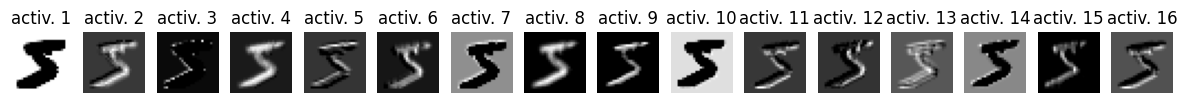

In [22]:

# Visualize the activations
num_activations = activations.shape[0]
fig, axes = plt.subplots(1, num_activations, figsize=(15, 3))

for i in range(num_activations):
    axes[i].imshow(activations[i], cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f'activ. {i+1}')

plt.show()


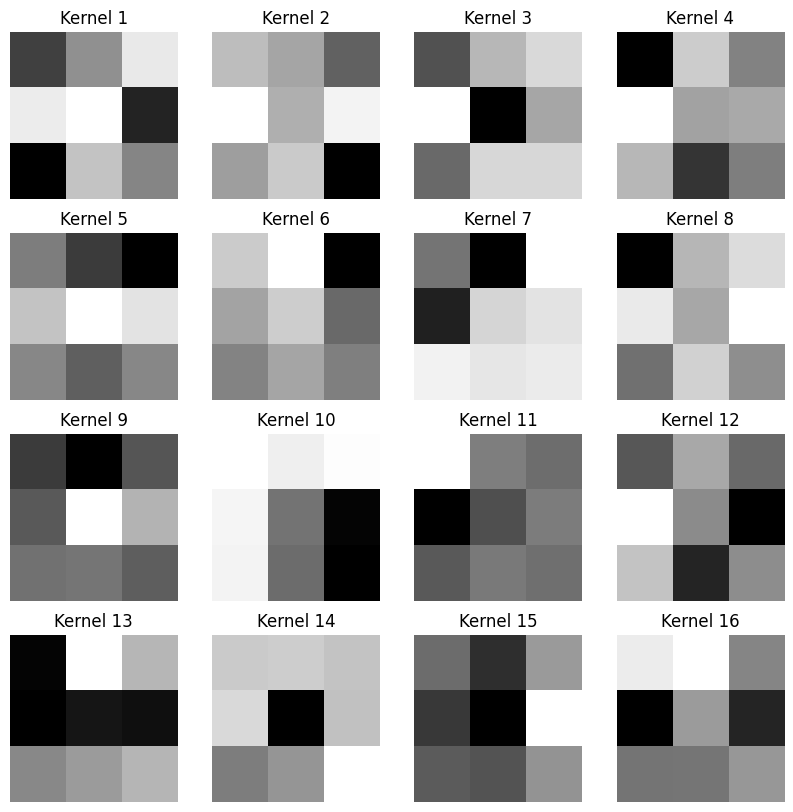

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Get the weights of the convolutional layer
conv_weights = model.encoder[0].weight.data.cpu().numpy()  # Assuming the convolutional layer is the first layer in the encoder

# Visualize the kernels
num_kernels = conv_weights.shape[0]
fig, axes = plt.subplots(num_kernels // 4, 4, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    ax.imshow(conv_weights[i, 0], cmap='gray')
    ax.axis('off')
    ax.set_title(f'Kernel {i+1}')

plt.show()


In [20]:
t = data[0][0].to(device)
t.shape

torch.Size([1, 28, 28])

In [21]:

with torch.no_grad():
    output = model.encoder(t)

print("Feature map for pixel at (0, 0):")
print(output[:, 0,0].shape, output.shape)

Feature map for pixel at (0, 0):
torch.Size([16]) torch.Size([16, 28, 28])
